# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [7]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 247ms
Checked 140 packages in 2ms


In [18]:
 # Fix dependency mismatch
!pip uninstall -y numpy scipy scikit-learn -q
!pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 -q

# Install required libs
!pip install -q huggingface_hub

import IPython
IPython.Application.instance().kernel.do_shutdown(True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nilearn 0.13.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
neuralset 0.0.2 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
mne 1.12.1 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
neuraltrain 0.0.2 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
tribev2 0.1.0 requires numpy==2.2.6, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
access 1.1.10.post3 requires s

{'status': 'ok', 'restart': True}

In [1]:
import os

 # Fix WhisperX float16 issue
os.environ["WHISPERX_FORCE_CPU"] = "1"
os.environ["CT2_COMPUTE_TYPE"] = "int8"

In [3]:
from huggingface_hub import login
login()

In [ ]:
import numpy as np
import json
import shutil
import pandas as pd
from pathlib import Path
from google.colab import files

from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain

CACHE_FOLDER  = Path("./cache")
OUTPUT_FOLDER = Path("./engram_outputs")   # ← all saved data lands here

CACHE_FOLDER.mkdir(exist_ok=True)
OUTPUT_FOLDER.mkdir(exist_ok=True)

print(f"Outputs will be saved to: {OUTPUT_FOLDER.resolve()}")

## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [4]:
# from tribev2.demo_utils import TribeModel, download_file
# from tribev2.plotting import PlotBrain
# from pathlib import Path

# CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")
print("Model loaded")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-27 05:59:31 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-27 06:00:17 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

In [ ]:
def extract_profile(preds, segments, ad_name):
    """
    Compresses (T, 20484) preds into a structured JSON-ready dict.
    This is what gets fed to the LLM for comparison.
    """
    profile = {}
    n_t, n_v = preds.shape

    # ── metadata ──────────────────────────────────────────────
    profile["ad_name"]   = ad_name
    profile["n_seconds"] = int(n_t)
    profile["n_vertices"]= int(n_v)

    # ── transcript / segment text ─────────────────────────────
    profile["transcript"] = []
    for i, seg in enumerate(segments):
        text = ""
        if hasattr(seg, "text"):
            text = str(seg.text)
        elif hasattr(seg, "__str__"):
            text = str(seg)
        profile["transcript"].append({"second": i, "text": text})

    # ── per-second engagement timeline ────────────────────────
    means = preds.mean(axis=1)                              # shape (T,)
    profile["engagement_per_second"] = [round(float(v), 4) for v in means]

    # ── summary stats ─────────────────────────────────────────
    profile["overall_mean"]          = round(float(means.mean()), 4)
    profile["overall_max"]           = round(float(means.max()),  4)
    profile["overall_min"]           = round(float(means.min()),  4)
    profile["peak_second"]           = int(means.argmax())
    profile["lowest_second"]         = int(means.argmin())
    profile["engagement_std"]        = round(float(means.std()),  4)  # consistency

    # ── active brain % per second ─────────────────────────────
    profile["active_vertices_pct"] = [
        round(float((preds[t] > 0.5).mean() * 100), 2)
        for t in range(n_t)
    ]
    profile["peak_active_pct"] = max(profile["active_vertices_pct"])

    # ── spatial distribution ──────────────────────────────────
    half = n_v // 2
    lh_mean = float(preds[:, :half].mean())
    rh_mean = float(preds[:, half:].mean())
    profile["left_hemisphere_mean"]  = round(lh_mean, 4)
    profile["right_hemisphere_mean"] = round(rh_mean, 4)
    profile["left_vs_right_ratio"]   = round(lh_mean / max(rh_mean, 0.001), 4)

    # posterior (visual/occipital) vs anterior (frontal/language)
    q = n_v // 4
    post = float(preds[:, :q].mean())
    ant  = float(preds[:, -q:].mean())
    profile["posterior_activation"]    = round(post, 4)
    profile["anterior_activation"]     = round(ant,  4)
    profile["posterior_vs_anterior"]   = round(post / max(ant, 0.001), 4)
    # >1.5 = visually dominant  |  <1.0 = concept/language dominant

    # ── engagement arc shape ──────────────────────────────────
    third = max(n_t // 3, 1)
    profile["opening_third_mean"] = round(float(means[:third].mean()),        4)
    profile["middle_third_mean"]  = round(float(means[third:2*third].mean()), 4)
    profile["closing_third_mean"] = round(float(means[2*third:].mean()),      4)

    arc = profile["opening_third_mean"]
    arc_close = profile["closing_third_mean"]
    if arc > arc_close + 0.2:
        profile["arc_shape"] = "front_loaded"
    elif arc_close > arc + 0.2:
        profile["arc_shape"] = "back_loaded"
    else:
        profile["arc_shape"] = "balanced"

    # ── pacing / volatility ───────────────────────────────────
    diffs = np.diff(means)
    profile["engagement_volatility"]  = round(float(np.abs(diffs).mean()), 4)
    # >0.4 = jarring pacing  |  <0.15 = very flat/stable
    profile["biggest_drop"]           = round(float(diffs.min()), 4)
    profile["biggest_spike"]          = round(float(diffs.max()), 4)
    profile["biggest_drop_at_second"] = int(np.argmin(diffs) + 1)
    profile["biggest_spike_at_second"]= int(np.argmax(diffs) + 1)

    # ── brand moment alignment ────────────────────────────────
    # Is the peak second close to when brand name appears in transcript?
    # (manual review needed — flagged here for LLM to interpret)
    profile["peak_second_text"] = profile["transcript"][profile["peak_second"]]["text"] \
        if profile["peak_second"] < len(profile["transcript"]) else ""

    return profile


## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [ ]:
print("Upload your video file...")
uploaded = files.upload()

uploaded_filename = list(uploaded.keys())[0]
video_path        = CACHE_FOLDER / uploaded_filename
shutil.move(uploaded_filename, video_path)

AD_NAME = uploaded_filename.rsplit(".", 1)[0]   # use filename as ad name
                                                 # change this manually if needed
print(f"Ad name set to: '{AD_NAME}'")

df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "text", "context"]])

In [ ]:
print("Running prediction — all modalities...")
preds_full, segments = model.predict(events=df)
print(f"Shape: {preds_full.shape}   (seconds x vertices)")

# ╔══════════════════════════════════════════════════════╗
# ║  SAVE POINT 1 — raw predictions array               ║
# ║  This is the source of truth. Save immediately.     ║
# ╚══════════════════════════════════════════════════════╝
np.save(OUTPUT_FOLDER / f"{AD_NAME}_preds_full.npy", preds_full)
print(f"SAVED: {AD_NAME}_preds_full.npy")


In [ ]:
# video_path = CACHE_FOLDER / "sample_video.mp4"
# url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
# download_file(url, video_path)
# df = model.get_events_dataframe(video_path=video_path)
# display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

# from google.colab import files
# import shutil

# uploaded = files.upload()

# uploaded_filename = list(uploaded.keys())[0]
# video_path = CACHE_FOLDER / uploaded_filename

# shutil.move(uploaded_filename, video_path)

# df = model.get_events_dataframe(video_path=video_path)

# display(df.head(8)[["type", "start", "duration", "text", "context"]])

### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [ ]:
print("\nRunning prediction — no audio...")
df_no_audio = df[df["type"] != "Audio"].copy().reset_index(drop=True)
preds_no_audio, _ = model.predict(events=df_no_audio)

# ╔══════════════════════════════════════════════════════╗
# ║  SAVE POINT 2 — no-audio predictions                ║
# ╚══════════════════════════════════════════════════════╝
np.save(OUTPUT_FOLDER / f"{AD_NAME}_preds_no_audio.npy", preds_no_audio)
print(f"SAVED: {AD_NAME}_preds_no_audio.npy")


# --- No video: remove Video rows ---
print("\nRunning prediction — no video...")
df_no_video = df[df["type"] != "Video"].copy().reset_index(drop=True)
preds_no_video, _ = model.predict(events=df_no_video)

# ╔══════════════════════════════════════════════════════════╗
# ║  SAVE POINT 3 — no-video predictions                    ║
# ╚══════════════════════════════════════════════════════════╝
np.save(OUTPUT_FOLDER / f"{AD_NAME}_preds_no_video.npy", preds_no_video)
print(f"SAVED: {AD_NAME}_preds_no_video.npy")


# --- No text: remove Word rows ---
print("\nRunning prediction — no text...")
df_no_text = df[df["type"] != "Word"].copy().reset_index(drop=True)
preds_no_text, _ = model.predict(events=df_no_text)

# ╔══════════════════════════════════════════════════════════╗
# ║  SAVE POINT 4 — no-text predictions                     ║
# ╚══════════════════════════════════════════════════════════╝
np.save(OUTPUT_FOLDER / f"{AD_NAME}_preds_no_text.npy", preds_no_text)
print(f"SAVED: {AD_NAME}_preds_no_text.npy")

print("\nAll modality runs complete.")

In [ ]:
profile = extract_profile(preds_full, segments, AD_NAME)

# Add modality contribution numbers to the profile
n_t = min(preds_full.shape[0], preds_no_audio.shape[0],
          preds_no_video.shape[0], preds_no_text.shape[0])

full_means   = preds_full[:n_t].mean(axis=1)
audio_means  = preds_no_audio[:n_t].mean(axis=1)
video_means  = preds_no_video[:n_t].mean(axis=1)
text_means   = preds_no_text[:n_t].mean(axis=1)

profile["modality"] = {
    "no_audio_mean_per_second": [round(float(v), 4) for v in audio_means],
    "no_video_mean_per_second": [round(float(v), 4) for v in video_means],
    "no_text_mean_per_second":  [round(float(v), 4) for v in text_means],

    # audio_drop_pct per second — how much engagement is lost without audio
    "audio_drop_pct_per_second": [
        round(float((full_means[t] - audio_means[t]) / max(full_means[t], 0.001) * 100), 2)
        for t in range(n_t)
    ],
    "video_drop_pct_per_second": [
        round(float((full_means[t] - video_means[t]) / max(full_means[t], 0.001) * 100), 2)
        for t in range(n_t)
    ],
    "text_drop_pct_per_second": [
        round(float((full_means[t] - text_means[t]) / max(full_means[t], 0.001) * 100), 2)
        for t in range(n_t)
    ],

    # overall average contribution across entire ad
    "avg_audio_contribution_pct": round(float(
        (full_means - audio_means).mean() / max(full_means.mean(), 0.001) * 100), 2),
    "avg_video_contribution_pct": round(float(
        (full_means - video_means).mean() / max(full_means.mean(), 0.001) * 100), 2),
    "avg_text_contribution_pct":  round(float(
        (full_means - text_means).mean()  / max(full_means.mean(), 0.001) * 100), 2),
}

# ╔══════════════════════════════════════════════════════════╗
# ║  SAVE POINT 5 — engagement profile JSON                 ║
# ║  THIS is what you feed the LLM for comparison           ║
# ╚══════════════════════════════════════════════════════════╝
profile_path = OUTPUT_FOLDER / f"{AD_NAME}_profile.json"
with open(profile_path, "w") as f:
    json.dump(profile, f, indent=2)
print(f"SAVED: {AD_NAME}_profile.json")
print("\nProfile preview:")
print(json.dumps(profile, indent=2))

In [7]:
# preds, segments = model.predict(events=df)
# print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[06:19:07 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-04-27 06:23:04 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 10.0s at 25.0fps, shape (1920, 1080)):
cache/TVS-4V-SBO-GPFILM-102LEDIT-10-ENG-HD.mov
DEBUG:neuralset.extractors.video:Loaded Video (duration 10.0s at 25.0fps, shape (1920, 1080)):
cache/TVS-4V-SBO-GPFILM-102LEDIT-10-ENG-HD.mov
Encoding video:   0%|          | 0/20 [00:00<?, ?it/s]2026-04-27 06:23:24 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (20, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (20, 20, 1408)
Encoding video: 100%|██████████| 20/20 [07:11<00:00, 21.56s/it]
[06:30:16 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-27 06:30:16 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[06:30:16 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torc

Predictions shape: (10, 20484)  (n_timesteps, n_vertices)


In [ ]:
n_t = preds_full.shape[0]
rows = []
for t in range(n_t):
    na_mean = float(preds_no_audio[t].mean()) if t < preds_no_audio.shape[0] else None
    nv_mean = float(preds_no_video[t].mean()) if t < preds_no_video.shape[0] else None
    nt_mean = float(preds_no_text[t].mean())  if t < preds_no_text.shape[0]  else None
    full_m  = float(preds_full[t].mean())

    rows.append({
        "second":               t,
        "full_mean":            round(full_m, 4),
        "full_max":             round(float(preds_full[t].max()), 4),
        "full_std":             round(float(preds_full[t].std()), 4),
        "active_vertices_pct":  round(float((preds_full[t] > 0.5).mean() * 100), 2),
        "no_audio_mean":        round(na_mean, 4) if na_mean else None,
        "no_video_mean":        round(nv_mean, 4) if nv_mean else None,
        "no_text_mean":         round(nt_mean, 4) if nt_mean else None,
        "audio_drop_pct":       round((full_m - na_mean) / max(full_m, 0.001) * 100, 2) if na_mean else None,
        "video_drop_pct":       round((full_m - nv_mean) / max(full_m, 0.001) * 100, 2) if nv_mean else None,
        "text_drop_pct":        round((full_m - nt_mean) / max(full_m, 0.001) * 100, 2) if nt_mean else None,
        "transcript_text":      profile["transcript"][t]["text"] if t < len(profile["transcript"]) else "",
    })

df_summary = pd.DataFrame(rows)

# ╔══════════════════════════════════════════════════════════╗
# ║  SAVE POINT 6 — per-second CSV                          ║
# ║  Use for charts, dashboards, and quick spreadsheet view ║
# ╚══════════════════════════════════════════════════════════╝
csv_path = OUTPUT_FOLDER / f"{AD_NAME}_summary.csv"
df_summary.to_csv(csv_path, index=False)
print(f"SAVED: {AD_NAME}_summary.csv")
print(df_summary.to_string())

In [ ]:
seg_data = []
for i, seg in enumerate(segments):
    entry = {"index": i}
    for attr in ["start", "duration", "text", "context", "filepath"]:
        if hasattr(seg, attr):
            val = getattr(seg, attr)
            entry[attr] = str(val) if val is not None else ""
    seg_data.append(entry)

# ╔══════════════════════════════════════════════════════════╗
# ║  SAVE POINT 7 — segments JSON                           ║
# ║  Time alignment reference for every other output        ║
# ╚══════════════════════════════════════════════════════════╝
seg_path = OUTPUT_FOLDER / f"{AD_NAME}_segments.json"
with open(seg_path, "w") as f:
    json.dump(seg_data, f, indent=2, default=str)
print(f"SAVED: {AD_NAME}_segments.json")


In [5]:
# # print(model.brain_model_config)
# # print("---")
# print(model.data)

NameError: name 'model' is not defined

In [14]:
# print(type(preds))
# print(preds.shape)
# print(len(segments))
# print(segments[0])

<class 'numpy.ndarray'>
(10, 20484)
10
Segment(start=0.0, duration=1.0, timeline='default', _trigger_idx=2)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 10/10 [00:03<00:00,  2.67it/s]


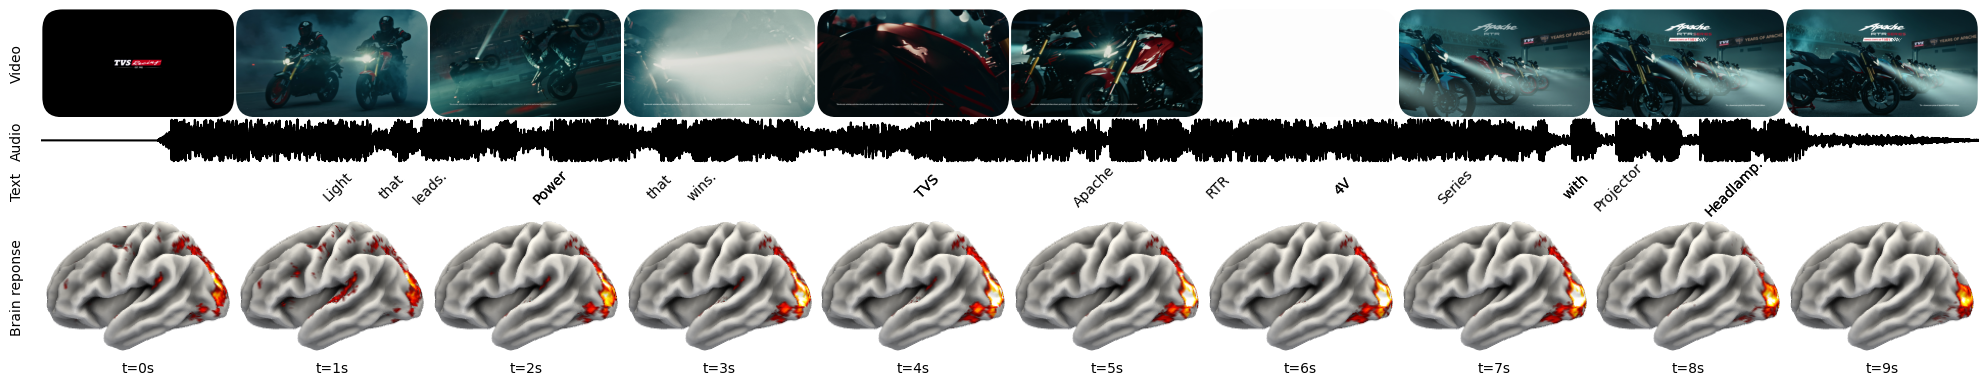

In [8]:
# n_timesteps = 60
# fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [ ]:
import matplotlib
matplotlib.use("Agg")

plots_folder = OUTPUT_FOLDER / f"{AD_NAME}_brain_plots"
plots_folder.mkdir(exist_ok=True)

n_timesteps = preds_full.shape[0]
fig = plotter.plot_timesteps(
    preds_full[:n_timesteps],
    segments=segments[:n_timesteps],
    cmap="fire",
    norm_percentile=99,
    vmin=0.6,
    alpha_cmap=(0, 0.2),
    show_stimuli=True
)

# ╔══════════════════════════════════════════════════════════╗
# ║  SAVE POINT 8 — brain plot figure                       ║
# ║  Visual confirmation the model ran correctly             ║
# ╚══════════════════════════════════════════════════════════╝
fig_path = OUTPUT_FOLDER / f"{AD_NAME}_brain_timeline.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"SAVED: {AD_NAME}_brain_timeline.png")

In [ ]:
print("\n=== ALL SAVED FILES ===")
for f in sorted(OUTPUT_FOLDER.iterdir()):
    size_kb = round(f.stat().st_size / 1024, 1)
    print(f"  {f.name:55s} {size_kb:>8.1f} KB")

# Zip and download everything
import zipfile
zip_path = f"{AD_NAME}_engram_outputs.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for file in OUTPUT_FOLDER.rglob("*"):
        if file.is_file():
            zf.write(file, file.relative_to(OUTPUT_FOLDER))

files.download(zip_path)
print(f"\nDownloading: {zip_path}")

In [ ]:
def build_llm_prompt(output_folder=OUTPUT_FOLDER):
    profile_files = sorted(Path(output_folder).glob("*_profile.json"))

    if len(profile_files) < 2:
        print("Need at least 2 profile JSONs for comparison.")
        print(f"Found: {[f.name for f in profile_files]}")
        return

    print(f"Found {len(profile_files)} profiles: {[f.name for f in profile_files]}")

    profiles = []
    for pf in profile_files:
        with open(pf) as f:
            profiles.append(json.load(f))

    prompt = """You are a media planning analyst. Below are neural engagement profiles
extracted from Meta's TRIBE v2 brain prediction model for {} ad creatives.
Each profile contains second-by-second predicted fMRI engagement scores and summary statistics.

INTERPRETATION GUIDE:
- Engagement scores are z-scored BOLD signal averages across 20,484 cortical vertices
- Typical range: 0.3 (low) to 2.0+ (peak engagement)
- posterior_vs_anterior > 1.5 = visually dominant ad (TV, YouTube suited)
- posterior_vs_anterior < 1.0 = concept/language dominant (audio, OTT suited)
- engagement_volatility > 0.4 = jarring pacing | < 0.15 = flat/too stable
- avg_audio_contribution_pct = how much the ad depends on sound (mute test)
- arc_shape: front_loaded / back_loaded / balanced

AD PROFILES:
{}

COMPARE THESE ADS ON:
1. Overall neural engagement ranking — which ad wins and by how much
2. Opening 3 seconds — which grabs attention fastest
3. Brand moment alignment — is peak_second close to when brand name appears in transcript
4. Visual vs language dominance — and what platform that implies
5. Pacing quality — which has the smoothest arc vs biggest drops
6. Sound dependency — which ad survives on mute (for digital/social)
7. Specific edit recommendations — which seconds to cut or restructure per ad
8. Platform recommendation per ad: TV / YouTube pre-roll / Instagram Stories / OTT / Radio
""".format(
        len(profiles),
        "\n\n".join([
            f"--- AD {i+1}: {p['ad_name']} ---\n{json.dumps(p, indent=2)}"
            for i, p in enumerate(profiles)
        ])
    )

    # Save the prompt to a file
    prompt_path = Path(output_folder) / "llm_comparison_prompt.txt"
    with open(prompt_path, "w") as f:
        f.write(prompt)

    print(f"\nPrompt saved to: llm_comparison_prompt.txt")
    print(f"Total prompt length: {len(prompt):,} characters")
    print("\n--- PROMPT PREVIEW (first 500 chars) ---")
    print(prompt[:500])
    print("...")

    return prompt

# Call this after running all your creatives through cells 8-14
# Then upload the saved profile JSONs here, or run everything in the same session
prompt = build_llm_prompt()


In [10]:
# tr = model.tr  # e.g. 1.49 or 2.0
# fig = plotter.plot_timesteps(
#     preds[:n_timesteps],
#     segments=segments[:n_timesteps],
#     cmap="fire",
#     norm_percentile=99,
#     vmin=.6,
#     alpha_cmap=(0, .2),
#     show_stimuli=True,
#     tr=tr  # pass this if the plotter accepts it
# )

AttributeError: 'TribeModel' object has no attribute 'tr'

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [ ]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

,type,start,duration,filepath,text,context
0,Audio,0.000000,23.256000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,1.261002,NaN,To be or not to be.,
2,Text,0.091000,22.590000,NaN,To be or not to be. That is the question. Whet...,
3,Word,0.091000,0.100000,NaN,To,To
4,Word,0.271000,0.200000,NaN,be,To be
5,Word,0.551000,0.060000,NaN,or,To be or
6,Word,0.691000,0.200000,NaN,not,To be or not
7,Word,0.931000,0.100000,NaN,to,To be or not to


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [ ]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[15:12:25 WARNING] Removing extractor video as there are no corresponding events
[15:12:25 INFO] Preparing extractor: text


[15:12:26 INFO] Preparing extractor: audio
Loading weights: 100%|██████████| 773/773 [00:00<00:00, 8813.53it/s]
[15:12:28 INFO] Preparing extractor: subject_id
2026-03-30 15:12:28 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'bar'}. This was probably not intended.
[15:12:29 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:01<00:00,  1.85s/it]
INFO - Predicted 24 / 100 segments (24.0% kept)


Predictions shape: (24, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...:   0%|          | 0/15 [00:00<?, ?it/s]

Plotting...: 100%|██████████| 15/15 [00:01<00:00, 11.59it/s]


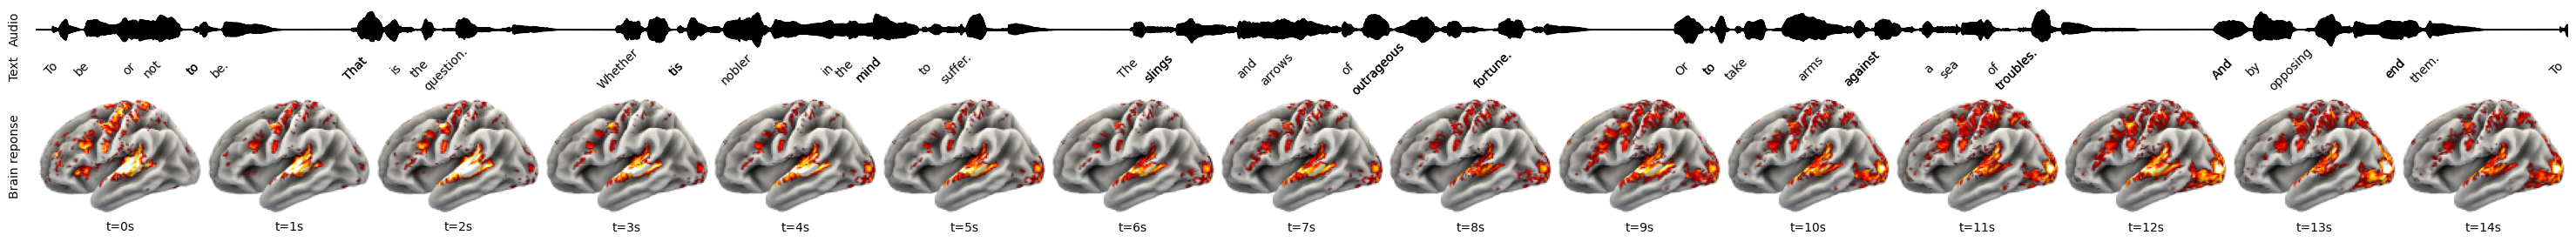

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)